<a href="https://colab.research.google.com/github/masikyy/Chicken-Diseases-Classification-Project/blob/main/analisis_resiko_saham.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analyzing and making prediction of Tech Stocks

Dalam project ini saya menggunakan pandas untuk menganalisis data, termasuk metrik nilai, resiko, dan imbal hasil dari perusahaan-perusahaan terkemuka "BTBAS": BBCA, Telkom, BBRI, ASII, dan SMGR. Berikut pertanyaan yang saya bahas:

- Bagaimana perubahan harga saham kita dari waktu ke waktu?
- Berapa average pergerakan harga saham kita?
- Berapa average imbal hasil harian suatu saham?
- Bagaimana Korelasi anatara imbal hasil harian berbagai saham?
- Seberapa besar nilai yang kita pertaruhkan dengan berinvestasi pada saham tertentu?
- Bagaimana kita dapat mencoba memprediksi perilaku saham "FAANG" di masa depan?

In [1]:
from __future__ import division
import pandas as pd
from pandas import Series, DataFrame
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline

from datetime import datetime
import yfinance as yf

import warnings
warnings.filterwarnings('ignore')

Saya akan membandingkan 5 perusahaan "BTBAS" untuk menganalisis harga saham rata-rata dan imbal hasilnya, guna melakukan penilaian risiko terhadap saham-saham tersebut selama 365 hari terakhir.

In [2]:
stock_list = ['BBCA.JK', 'TLKM.JK', 'BBRI.JK', 'ASII.JK', 'SMGR.JK']

end = datetime.now()

#tanggal mulai ditetapkan 1 tahun kebelakang
start = datetime(end.year - 1, end.month, end.day)

for stock in stock_list:
  globals()[stock.replace('.', '_')] = yf.download(stock, start, end)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [3]:
BBCA_JK.describe()

Price,Close,High,Low,Open,Volume
Ticker,BBCA.JK,BBCA.JK,BBCA.JK,BBCA.JK,BBCA.JK
count,238.000000,238.000000,238.000000,238.000000,2.380000e+02
mean,7703.929458,7789.742198,7636.114596,7713.018680,1.474623e+08
std,671.766965,663.474573,673.897246,677.155429,1.329371e+08
min,6419.000000,6500.000000,6107.630971,6395.048860,4.133730e+07
25%,7185.447754,7304.915674,7137.723690,7191.796677,8.303128e+07
50%,7832.138184,7947.262343,7724.356542,7852.085597,1.146084e+08
75%,8137.616211,8232.792969,8084.079145,8161.410161,1.608316e+08
max,9232.149414,9327.326728,9184.561523,9327.326728,1.432993e+09


In [4]:
BBCA_JK.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 238 entries, 2025-04-23 to 2026-04-22
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, BBCA.JK)   238 non-null    float64
 1   (High, BBCA.JK)    238 non-null    float64
 2   (Low, BBCA.JK)     238 non-null    float64
 3   (Open, BBCA.JK)    238 non-null    float64
 4   (Volume, BBCA.JK)  238 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.2 KB


# Perubahan saham dari waktu ke waktu

In [5]:
!pip install mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 982.0 kB/s eta 0:00:00


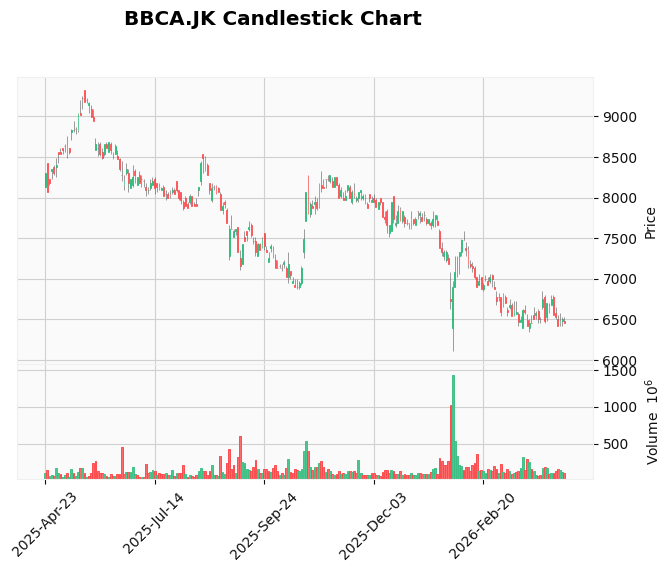

In [6]:
import mplfinance as mpf

# Prepare data for candlestick chart
df_candle = BBCA_JK[[('Open', 'BBCA.JK'), ('High', 'BBCA.JK'), ('Low', 'BBCA.JK'), ('Close', 'BBCA.JK'), ('Volume', 'BBCA.JK')]]
df_candle.columns = ['Open', 'High', 'Low', 'Close', 'Volume']

# Plot candlestick chart
mpf.plot(df_candle, type='candle', style='yahoo', title='BBCA.JK Candlestick Chart', ylabel='Price', volume=True)

<Axes: xlabel='Date'>

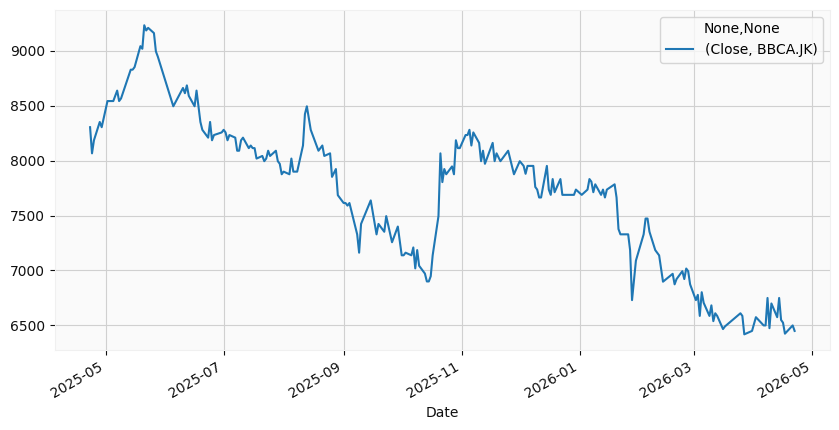

In [7]:
BBCA_JK[('Close', 'BBCA.JK')].plot(legend = True, figsize = (10,5))

<Axes: xlabel='Date'>

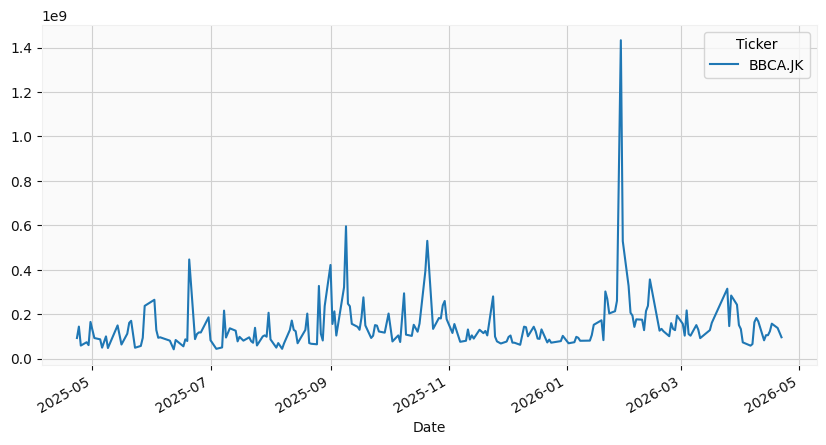

In [8]:
BBCA_JK['Volume'].plot(legend=True, figsize=(10, 5))

Setelah mencapai puncaknya diatas **Rp9.200** pada pertengahan 2025, harga saham **BBCA** mengalami tren penurunan yang konsisten dan kini berfluktuasi di kisaran **Rp6.500 hingga Rp7.000.** Meskipun aktivitas perdagangan harian rata-rata stabil, terlihat lonjakan volume yang sangat masif hingga lebih dari **1,4 Miliar** lembar saham pada Februari 2025. Now, lets go kita hitung beberapa *moving average* yang berbeda untuk menghaluskan variasi data dan mendapatkan tren yang lebih jelas.

# Menghitung Moving Average

In [9]:
averages = [10, 25, 50]
for avg in averages:
  label = "MAvg for %s days" %(str(avg))
  BBCA_JK[label] = BBCA_JK['Close', 'BBCA.JK'].rolling(window=avg, center=False).mean()

In [10]:
BBCA_JK.tail()

Price,Close,High,Low,Open,Volume,MAvg for 10 days,MAvg for 25 days,MAvg for 50 days
Ticker,BBCA.JK,BBCA.JK,BBCA.JK,BBCA.JK,BBCA.JK,,,
Date,,,,,,,,
2026-04-16,6525.0,6650.0,6500.0,6575.0,122416100,6590.0,6575.513242,6805.272910
2026-04-17,6425.0,6550.0,6425.0,6500.0,156827000,6575.0,6560.424277,6790.063955
2026-04-20,6475.0,6575.0,6425.0,6450.0,137435700,6572.5,6551.167559,6784.956562
2026-04-21,6500.0,6525.0,6425.0,6475.0,112151900,6572.5,6547.701133,6776.995957
2026-04-22,6450.0,6525.0,6450.0,6475.0,95673700,6542.5,6538.402461,6764.203115


In [11]:
print(BBCA_JK.columns)
print(BBCA_JK.columns.names)

MultiIndex([(           'Close', 'BBCA.JK'),
            (            'High', 'BBCA.JK'),
            (             'Low', 'BBCA.JK'),
            (            'Open', 'BBCA.JK'),
            (          'Volume', 'BBCA.JK'),
            ('MAvg for 10 days',        ''),
            ('MAvg for 25 days',        ''),
            ('MAvg for 50 days',        '')],
           names=['Price', 'Ticker'])
['Price', 'Ticker']


<Axes: xlabel='Date'>

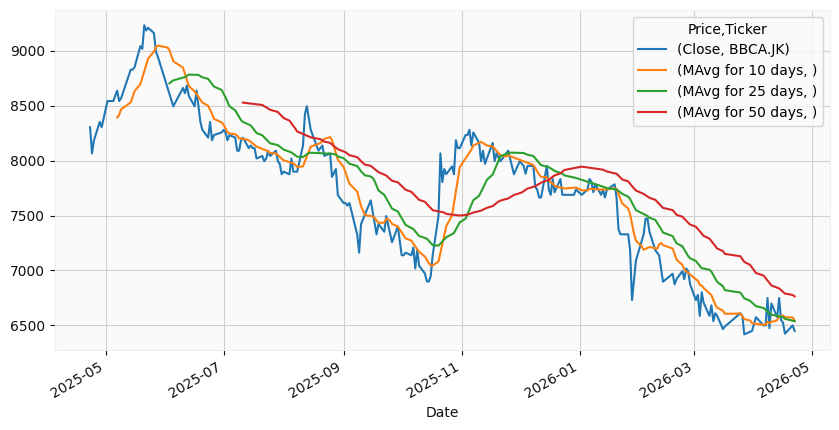

In [12]:
BBCA_JK[[('Close', 'BBCA.JK'), ('MAvg for 10 days', ''), ('MAvg for 25 days', ''), ('MAvg for 50 days', '')]].plot(figsize=(10, 5))

Melalui analisi Movinga Average, terlihat bahwa saham BBCA berada dalam tren penurunan yang kuat sejak pertengahan 2025, dimana garai MA 50 bertindak sebagai resistance yang sulit ditembus. Meskipun sempat menjadi upaya kenaikan pada November 2025, harga kembali tertekan dibawah rata-rata jangka menengahnya. Saat ini garis MA 50 terus melandai ke arah Rp6.800, menunjukan bahwa tekanan jual masih mendominasi pergerakan pasar. Kita perlu memperhatikan titik potong (corssover) baru untuk melihat potensi pembalikan arah tren di masa depan.

Saay ini (April 2026), garis biru atau harga close mulai mendatar dan mendekati garis orange dan hijau. Jika garis biru bisa menembus ke atas garis merah (MA 50) dan bertahan, maka itu adalah indikasi awal bahwa BBCA mungkin sudah selesai "masa sulitnya" dan siap untuk naik lagi.

# Rata-rata Return Harian

kolom rata rata retrun harian dibuat menggunakan persentase perubahan terhadap harga penutupan yang disesuaikan

In [13]:
BBCA_JK['daily_return'] = BBCA_JK['Close', 'BBCA.JK'].pct_change()
BBCA_JK.tail()

Price,Close,High,Low,Open,Volume,MAvg for 10 days,MAvg for 25 days,MAvg for 50 days,daily_return
Ticker,BBCA.JK,BBCA.JK,BBCA.JK,BBCA.JK,BBCA.JK,,,,
Date,,,,,,,,,
2026-04-16,6525.0,6650.0,6500.0,6575.0,122416100,6590.0,6575.513242,6805.272910,-0.003817
2026-04-17,6425.0,6550.0,6425.0,6500.0,156827000,6575.0,6560.424277,6790.063955,-0.015326
2026-04-20,6475.0,6575.0,6425.0,6450.0,137435700,6572.5,6551.167559,6784.956562,0.007782
2026-04-21,6500.0,6525.0,6425.0,6475.0,112151900,6572.5,6547.701133,6776.995957,0.003861
2026-04-22,6450.0,6525.0,6450.0,6475.0,95673700,6542.5,6538.402461,6764.203115,-0.007692


<Axes: xlabel='Date'>

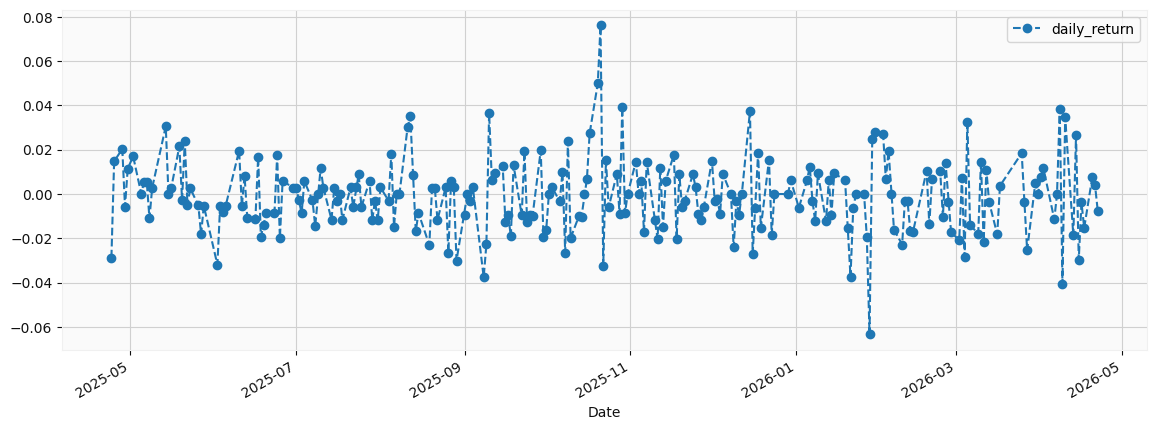

In [14]:
BBCA_JK['daily_return'].plot(figsize=(14, 5), legend=True, linestyle='--', marker='o')

Rata-rata imbal hasil harian (daily return) saham BBCA menunjukkan tingkat volatilitas yang cenderung stabil di kisaran +/- 2% per hari. Namun, terdapat fluktuasi signifikan di awal tahun 2026 di mana saham sempat mengalami koreksi harian yang cukup dalam melebihi 6%. Secara keseluruhan, meskipun harga sahamnya sedang dalam tren menurun (seperti yang kita lihat di grafik MA sebelumnya), pergerakan hariannya masih mencerminkan karakteristik saham blue chip yang tidak terlalu liar, kecuali pada momen-momen tertentu yang memicu kepanikan pasar.

<Axes: xlabel='daily_return', ylabel='Density'>

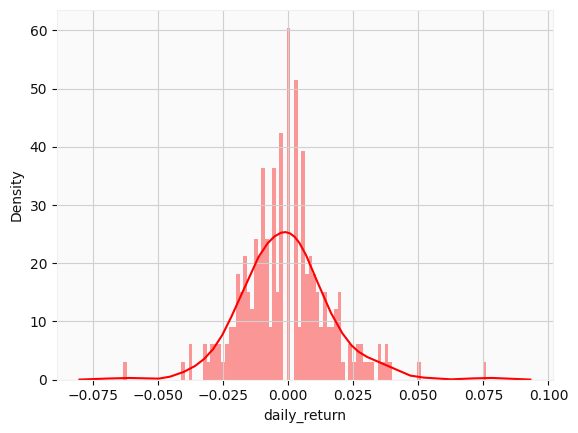

In [15]:
sns.distplot(BBCA_JK['daily_return'].dropna(), bins=100, color='red')

Distribusi imbal hasil harian (daily return) BBCA membentuk pola lonceng yang berpusat di angka nol, yang menunjukkan bahwa saham ini memiliki stabilitas tinggi dengan risiko yang terukur. Mayoritas pergerakan harian berkumpul di kisaran sempit antara -2,5% hingga +2,5%. Meskipun terdapat beberapa outlier atau pergerakan ekstrem di atas 7%, frekuensinya sangat jarang terjadi, sehingga mempertegas profil BBCA sebagai aset investasi dengan volatilitas yang relatif rendah dibandingkan saham lapis kedua atau ketiga.

# Korelasi Antara Return Saham yang Berbeda

Sekarang kita telusuri tren antara beberapa pasang saham "BTBAS" menggunakan fitur join plot dari Seaborn, dengan menggunakan persentase perubahan return harian.

In [16]:
close_compr = yf.download(stock_list, start, end)['Close']
rets_compr = close_compr.pct_change()
rets_compr.tail()

[*********************100%***********************]  5 of 5 completed


Ticker,ASII.JK,BBCA.JK,BBRI.JK,SMGR.JK,TLKM.JK
Date,,,,,
2026-04-16,-0.015873,-0.003817,0.002941,0.037500,0.009709
2026-04-17,0.028226,-0.015326,0.005865,-0.004016,-0.006410
2026-04-20,-0.003922,0.007782,0.002915,-0.036290,0.000000
2026-04-21,-0.003937,0.003861,0.012071,-0.004184,-0.029032
2026-04-22,0.043478,-0.007692,-0.009174,0.004202,-0.003322


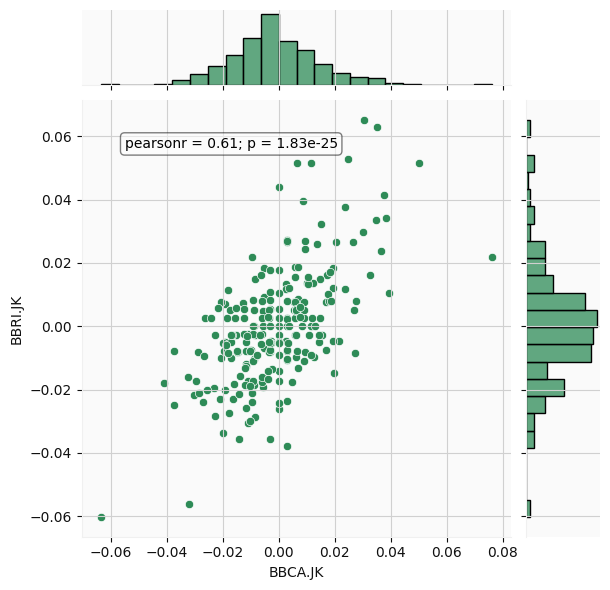

In [17]:
from scipy.stats import pearsonr

# sns.jointplot(x='BBCA.JK', y='BBRI.JK', data=rets_compr, kind='scatter', color='seagreen')

# 1. Buat grafik jointplot dan simpan ke dalam variabel (misal: 'g')
g = sns.jointplot(x='BBCA.JK', y='BBRI.JK', data=rets_compr, kind='scatter', color='seagreen')

# 2. Hitung korelasi Pearson menggunakan scipy
# Kita gunakan .dropna() agar data yang kosong tidak menyebabkan error
r, p = pearsonr(rets_compr['BBCA.JK'].dropna(), rets_compr['BBRI.JK'].dropna())

# 3. Tambahkan teks korelasi ke dalam grafik secara manual
# Kita letakkan di 'ax_joint' (area grafik scatter-nya)
g.ax_joint.annotate(f'pearsonr = {r:.2f}; p = {p:.2e}',
                    xy=(0.1, 0.9), xycoords='axes fraction',
                    ha='left', va='center',
                    bbox=dict(boxstyle='round', fc='white', alpha=0.5))

plt.show()

Tampaknya ada korelasi yang cukup kuat antara kinerja BBCA dan BBRI. Saya akan membuat semua grafik pasangan untuk melihat apakah ada korelasi yang lebih kuat.

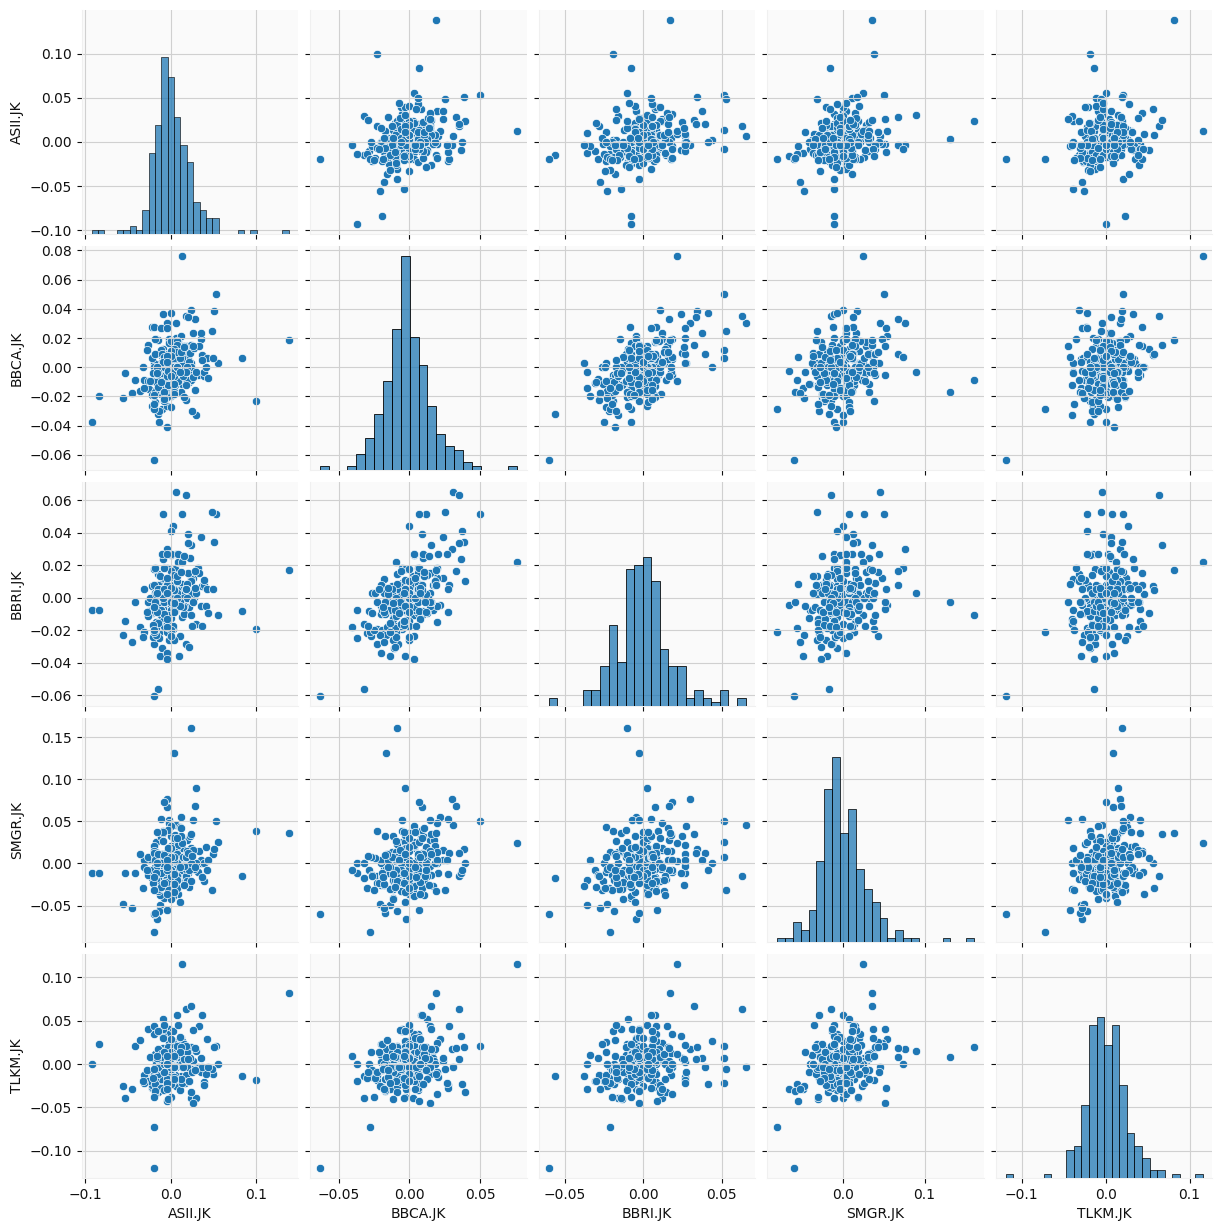

In [18]:
sns.pairplot(rets_compr.dropna())

Analisis pairplot pada portofolio 'BTBAS' menunjukkan bahwa korelasi terkuat terdapat pada pasangan saham BBCA.JK dan BBRI.JK. Hal ini wajar karena keduanya berada di sektor yang sama (Perbankan) dan memiliki kapitalisasi pasar besar yang menjadi penggerak utama IHSG. Sementara itu, saham lain seperti TLKM.JK dan SMGR.JK menunjukkan korelasi yang lebih rendah terhadap satu sama lain, yang berarti pasangan saham tersebut memberikan manfaat diversifikasi yang lebih baik bagi investor karena tidak selalu bergerak searah.

Ticker    ASII.JK   BBCA.JK   BBRI.JK   SMGR.JK   TLKM.JK
Ticker                                                   
ASII.JK  1.000000  0.305291  0.277885  0.257226  0.193257
BBCA.JK  0.305291  1.000000  0.609159  0.283986  0.377155
BBRI.JK  0.277885  0.609159  1.000000  0.274931  0.287747
SMGR.JK  0.257226  0.283986  0.274931  1.000000  0.296806
TLKM.JK  0.193257  0.377155  0.287747  0.296806  1.000000


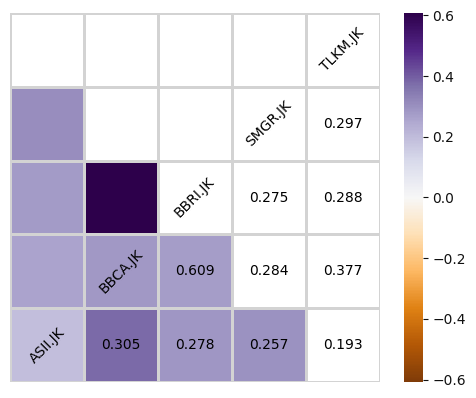

In [21]:
corr = rets_compr.corr()
__builtins__.print(corr)
# Generate a mask for the upper triangle
mask = np.zeros_like(corr, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
fig, ax = plt.subplots()

# Draw the heatmap with the mask and correct aspect ratio
vmax = np.abs(corr.values[~mask]).max()
sns.heatmap(corr, mask=mask, cmap=plt.cm.PuOr, vmin=-vmax, vmax=vmax,
            square=True, linecolor="lightgray", linewidths=1, ax=ax)
for i in range(len(corr)):
    ax.text(i+0.5,len(corr)-(i+0.5), corr.columns[i],
            ha="center", va="center", rotation=45)
    for j in range(i+1, len(corr)):
        s = "{:.3f}".format(corr.values[i,j])
        ax.text(j+0.5,len(corr)-(i+0.5),s,
            ha="center", va="center")
ax.axis("off")
plt.show()

Analisis Matriks dan Heatmap:

Korelasi Terkuat: Seperti yang ditunjukkan sebelumnya, BBCA.JK (Bank Central Asia) dan BBRI.JK (Bank Rakyat Indonesia) memiliki korelasi tertinggi, yaitu 0.609. Ini masuk akal karena keduanya adalah bank besar dan cenderung dipengaruhi oleh faktor ekonomi makro yang serupa.
Korelasi Moderat: BBCA.JK juga memiliki korelasi yang cukup signifikan dengan TLKM.JK (Telkom Indonesia) sebesar 0.377.
Korelasi Lebih Rendah: Saham-saham seperti ASII.JK (Astra International) dan SMGR.JK (Semen Indonesia) menunjukkan korelasi yang lebih rendah satu sama lain dan juga dengan saham bank, yang mengindikasikan manfaat diversifikasi jika dimasukkan dalam portofolio yang sama.

# Menentukan Nilai dari Perbandingan Risiko dan Imbal Hasil yang Diharapkan

Sekarang kita akan membahas masalah risiko dalam membeli saham untuk membandingkan 5 perusahaan tersebut

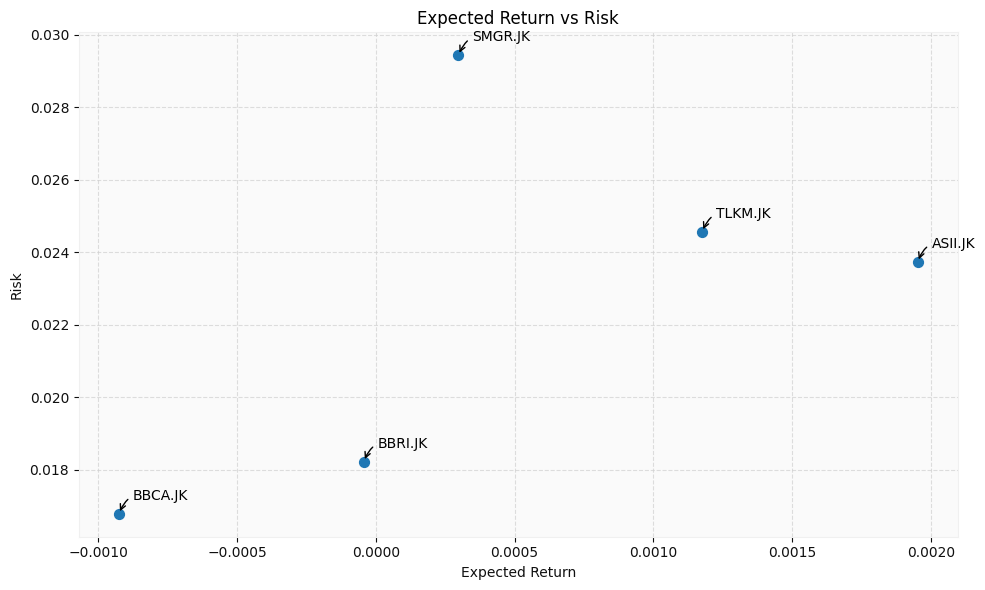

In [25]:
rets_filled = rets_compr.dropna()
plt.figure(figsize=(10,6)) # Mengubah ukuran figure agar lebih lebar dan tinggi

plt.scatter(rets_filled.mean(), rets_filled.std(), s=50) # Meningkatkan ukuran titik scatter

plt.xlabel('Expected Return')
plt.ylabel('Risk')
plt.title('Expected Return vs Risk')
plt.grid(True, linestyle='--', alpha=0.7) # Menambahkan grid untuk mempermudah pembacaan

for label, x, y in zip(rets_filled.columns, rets_filled.mean(), rets_filled.std()):
  plt.annotate(
      label,
      xy=(x, y), xytext=(10, 10), # Menyesuaikan posisi teks agar tidak terlalu jauh
      textcoords= 'offset points',
      arrowprops= dict(arrowstyle='->', connectionstyle='arc3,rad=0.5')
  )

plt.tight_layout() # Menyesuaikan layout agar semua elemen fit
plt.show()

Observasi dari Grafik:

ASII.JK (Astra International): Terlihat berada di posisi paling atas dan agak ke kanan. Ini menunjukkan bahwa ASII.JK memiliki risiko yang paling tinggi di antara kelima saham, tetapi juga menawarkan imbal hasil harian yang diharapkan relatif tinggi dibandingkan dengan yang lain.
BBCA.JK (Bank Central Asia): Berada di bagian bawah tengah, menunjukkan risiko yang relatif rendah (standar deviasi kecil) namun dengan imbal hasil harian yang juga tidak terlalu tinggi. Ini konsisten dengan sifat saham blue chip yang cenderung stabil.
BBRI.JK (Bank Rakyat Indonesia): Mirip dengan BBCA.JK, BBRI.JK juga menunjukkan profil risiko yang relatif rendah dengan imbal hasil harian moderat, sedikit lebih tinggi dari BBCA.JK.
TLKM.JK (Telkom Indonesia): Berada di area risiko dan imbal hasil yang moderat, tidak terlalu tinggi maupun rendah dibandingkan saham lain.
SMGR.JK (Semen Indonesia): Memiliki risiko yang relatif menengah dengan imbal hasil yang diharapkan berada di bawah rata-rata.
Kesimpulan:

Investor yang mencari risiko rendah dan stabilitas mungkin akan mempertimbangkan BBCA.JK atau BBRI.JK.
Investor yang bersedia mengambil risiko lebih tinggi untuk potensi imbal hasil lebih tinggi mungkin akan tertarik pada ASII.JK.
Grafik ini memberikan gambaran visual yang bagus untuk membandingkan karakteristik risiko dan imbal hasil dari berbagai saham dalam portofolio Anda.

oke selanjutna saya akan membaut model metrik nilai pada resiko tambahan untuk menilai nilai pada setiap interval kepercayaan risiko untuk 5 perusahaan ini. lets go kita coba dengan 2 cara : bootstraping dan monte carlo-GBM dengan google


In [26]:
rets_compr.head()

Ticker,ASII.JK,BBCA.JK,BBRI.JK,SMGR.JK,TLKM.JK
Date,,,,,
2025-04-23,NaN,NaN,NaN,NaN,NaN
2025-04-24,-0.010373,-0.028653,-0.007979,-0.007843,0.000000
2025-04-25,0.018868,0.014749,0.002681,0.027668,-0.011407
2025-04-28,0.006173,0.020349,0.026738,-0.011538,-0.015385
2025-04-29,-0.018405,-0.005698,0.002604,-0.003891,0.011719


In [29]:
rets_compr['BBRI.JK'].quantile(q=0.05)

np.float64(-0.025867950478966485)

In [30]:
rets_compr['BBRI.JK'].quantile(q=0.01)

np.float64(-0.0369777552256319)

Angka-angka ini memberikan gambaran tentang kerugian terburuk yang bisa diharapkan pada tingkat kepercayaan tertentu. Misalnya, jika Anda berinvestasi di BBRI.JK, pada 95% hari perdagangan, Anda tidak akan kehilangan lebih dari 2.5867% dari nilai investasi Anda dalam satu hari. Namun, ada 1% kemungkinan Anda bisa kehilangan lebih dari 3.6977% dalam satu hari. Investor menggunakan metrik ini untuk mengukur potensi kerugian dan mengelola eksposur risiko mereka.

# Memprediksi Risiko dan Nilai Saham di Masa Depan

Saya akan menerapkan Metode Monte CArlo pada model GBM untuk mengevaluasi stabilitas dan memprediksi risiko masa depan saham-saham saya. Saya akan menganalisis saham BBRI

In [32]:
day = 365

#delta t
dt = 1/365

mu = rets_compr.mean()['BBRI.JK']

sigma = rets_compr.std()['BBRI.JK']

# S0 = BBCA_JK['Close', 'BBCA.JK'][-1]

def stock_monte_carlo(start_price, days, mu, sigma):
  price = np.zeros(days)
  price[0] = start_price

  shock = np.zeros(days)
  drift = np.zeros(days)

  for x in range (1, days):
    #Rumus shock dan drift diambil dari Rumus Monte Carlo
    shock[x] = np.random.normal(loc=mu*dt, scale=sigma*np.sqrt(dt))
    drift[x] = mu*dt

    #new price = old price + old price*(shock+drift)
    price[x] = price[x-1] + price[x-1] * (shock[x]+drift[x])

  return price

Saya akan menjalankan 100 simulasi monte carlo untuk saham BBRI. Berikut ini nilai pembukaan saham tersebut

In [34]:
BBRI_JK.head()

Price,Close,High,Low,Open,Volume
Ticker,BBRI.JK,BBRI.JK,BBRI.JK,BBRI.JK,BBRI.JK
Date,,,,,
2025-04-23,3403.562744,3430.718830,3294.938401,3313.042458,432999900
2025-04-24,3376.406494,3475.978804,3367.354466,3430.718663,272537300
2025-04-25,3385.458740,3430.718884,3376.406712,3412.614826,136517100
2025-04-28,3475.978760,3485.030788,3421.666592,3430.718620,212945800
2025-04-29,3485.031006,3503.135063,3457.874920,3494.083034,160631400


Text(0.5, 1.0, 'Monte Carlo Analysis for BBRI')

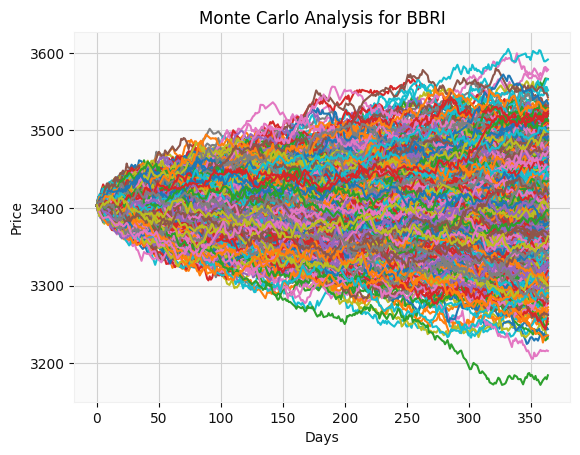

In [36]:
start_price = 3403.562744 #Taken from above

for run in range(1, 1000):
  plt.plot(stock_monte_carlo(start_price, day, mu, sigma))

plt.xlabel('Days')
plt.ylabel('Price')
plt.title('Monte Carlo Analysis for BBRI')

Text(0.5, 1.0, 'Final price distribution for Google Stock after 365 days')

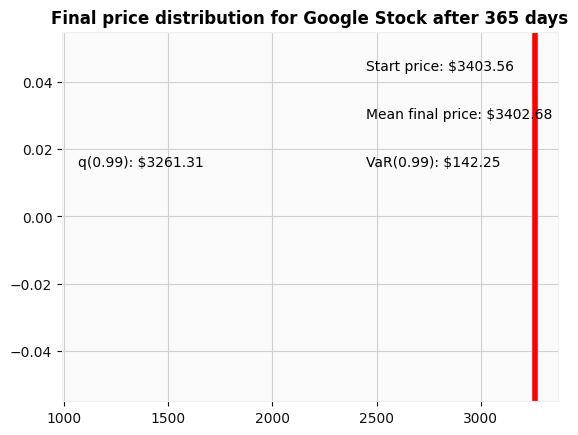

In [39]:
runs = 10000

simulations = np.zeros(runs)

for run in range(1,runs):
    simulations[run] = stock_monte_carlo(start_price,day,mu,sigma)[day-1]
q = np.percentile(simulations,1)

plt.hist(simulations,bins=200,range = [1100,1300])

plt.figtext(0.6,0.8,s="Start price: $%.2f" %start_price)

plt.figtext(0.6,0.7,"Mean final price: $%.2f" % simulations.mean())

plt.figtext(0.6,0.6,"VaR(0.99): $%.2f" % (start_price -q,))

plt.figtext(0.15,0.6, "q(0.99): $%.2f" % q)

plt.axvline(x=q, linewidth=4, color='r')

plt.title(u"Final price distribution for Google Stock after %s days" %day, weight='bold')